MUSIC

Параметры:
  Частота дискретизации: 48000 Гц
  Длительность сигнала: 0.2 с
  Частота сигнала: 440 Гц
  Скорость звука: 340 м/с
  Угол источника: 30°
  Расстояние: 3.0 м
  SNR: 30 дБ
  Микрофонов: 8, шаг: 5 см

1. Генерация сигналов...
   Размерность X: (8, 9600)
   Теоретические задержки (относительно центра):
     τ_1 = -0.000257 с
     τ_2 = -0.000184 с
     τ_3 = -0.000110 с
     τ_4 = -0.000037 с
     τ_5 = 0.000037 с
     τ_6 = 0.000110 с
     τ_7 = 0.000184 с
     τ_8 = 0.000257 с

2. MUSIC оценка...

   Собственные значения:
     λ_1 = 0.222029
     λ_2 = 0.000328
     λ_3 = 0.000289
     λ_4 = 0.000275
   Отношение λ₁/λ₂: 677.64

3. РЕЗУЛЬТАТЫ:
   Истинный угол: 30°
   Оцененный угол: 29.50°
   Ошибка: 0.50°


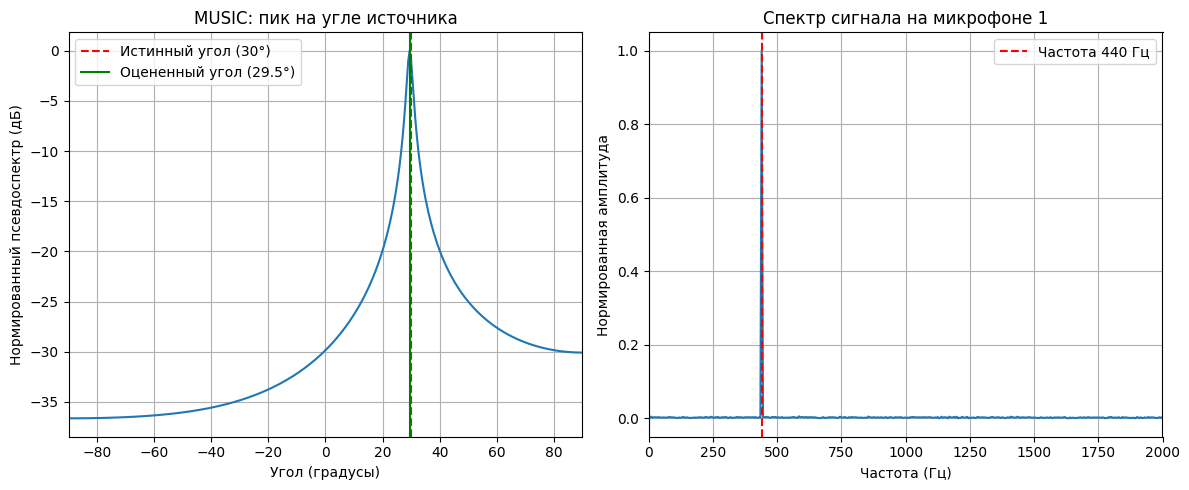

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Генерация данных

def generate_harmonic_signal(fs, T, f0, A=1.0):
    t = np.arange(0, T, 1/fs)
    s = A * np.cos(2 * np.pi * f0 * t)
    return t, s

def generate_array_signals(s, t, d, theta, R=3.0, SNR_dB=20, c=340, fs=None):
    M = len(d)
    L = len(s)
    theta_rad = np.deg2rad(theta)
    tau = d * np.sin(theta_rad) / c
    if fs is not None:
        tau_samps = tau * fs
        delay_samples = np.round(tau_samps).astype(int)
    else:
        delay_samples = np.round(tau * fs).astype(int)

    attenuation = 1.0 / R
    X = np.zeros((M, L))
    for m in range(M):
        s_delayed = np.roll(s, delay_samples[m])
        if delay_samples[m] > 0:
            s_delayed[:delay_samples[m]] = 0
        elif delay_samples[m] < 0:
            s_delayed[delay_samples[m]:] = 0

        signal_power = np.mean(s_delayed**2)
        noise_power = signal_power / (10**(SNR_dB/10))
        noise = np.sqrt(noise_power) * np.random.randn(L)
        X[m, :] = attenuation * s_delayed + noise
    return X, tau

# 2. MUSIC

def music_doa(X, d, theta_range, f0, c=340):
    M = X.shape[0]
    L = X.shape[1]

    # преобразование в аналитический сигнал
    X_complex = np.zeros((M, L), dtype=complex)
    for m in range(M):
        X_fft = np.fft.fft(X[m, :])
        X_fft[L//2+1:] = 0
        X_complex[m, :] = np.fft.ifft(X_fft)

    # ковариационная матрица
    R = np.zeros((M, M), dtype=complex)
    for n in range(L):
        x = X_complex[:, n]
        R += np.outer(x, np.conj(x))
    R /= L

    # регуляризация
    R += 1e-6 * np.trace(R) * np.eye(M)

    # собственные значения
    eigvals, eigvecs = np.linalg.eigh(R)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # шумовое подпространство
    K = 1
    U_n = eigvecs[:, K:]

    # псевдоспектр
    spectrum = np.zeros(len(theta_range))
    theta_rad = np.deg2rad(theta_range)

    for i, th in enumerate(theta_rad):
        a = np.exp(-1j * 2 * np.pi * f0 * d * np.sin(th) / c)
        denominator = np.linalg.norm(np.conj(a) @ U_n, ord=2) ** 2
        spectrum[i] = 1.0 / (denominator + 1e-12)

    return spectrum, eigvals

# 3. Запуск

if __name__ == "__main__":
    print("MUSIC")

    # параметры
    fs = 48000
    T = 0.2
    M = 8
    delta_d = 0.05
    theta_true = 30
    R = 3.0
    SNR_dB = 30
    f0 = 440
    c = 340

    print(f"\nПараметры:")
    print(f"  Частота дискретизации: {fs} Гц")
    print(f"  Длительность сигнала: {T} с")
    print(f"  Частота сигнала: {f0} Гц")
    print(f"  Скорость звука: {c} м/с")
    print(f"  Угол источника: {theta_true}°")
    print(f"  Расстояние: {R} м")
    print(f"  SNR: {SNR_dB} дБ")
    print(f"  Микрофонов: {M}, шаг: {delta_d*100:.0f} см")

    d = (np.arange(M) - (M - 1) / 2) * delta_d

    t, s = generate_harmonic_signal(fs, T, f0)
    X, tau_true = generate_array_signals(s, t, d, theta_true, R, SNR_dB, fs=fs, c=c)

    print(f"\n1. Генерация сигналов...")
    print(f"   Размерность X: {X.shape}")
    print(f"   Теоретические задержки (относительно центра):")
    for m in range(M):
        print(f"     τ_{m+1} = {tau_true[m]:.6f} с")

    print("\n2. MUSIC оценка...")
    theta_range = np.linspace(-90, 90, 361)
    spectrum, eigvals = music_doa(X, d, theta_range, f0, c=c)

    idx_max = np.argmax(spectrum)
    theta_est = theta_range[idx_max]

    print(f"\n   Собственные значения:")
    for i in range(min(4, M)):
        print(f"     λ_{i+1} = {eigvals[i]:.6f}")
    print(f"   Отношение λ₁/λ₂: {eigvals[0]/eigvals[1]:.2f}")

    print("\n3. РЕЗУЛЬТАТЫ:")
    print(f"   Истинный угол: {theta_true}°")
    print(f"   Оцененный угол: {theta_est:.2f}°")
    print(f"   Ошибка: {abs(theta_est - theta_true):.2f}°")

    # визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # MUSIC спектр
    axes[0].plot(theta_range, 10 * np.log10(spectrum / np.max(spectrum) + 1e-12))
    axes[0].axvline(theta_true, color='r', linestyle='--', label=f'Истинный угол ({theta_true}°)')
    axes[0].axvline(theta_est, color='g', linestyle='-', label=f'Оцененный угол ({theta_est:.1f}°)')
    axes[0].set_xlabel('Угол (градусы)')
    axes[0].set_ylabel('Нормированный псевдоспектр (дБ)')
    axes[0].set_title('MUSIC: пик на угле источника')
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_xlim(-90, 90)

    # спектр сигнала
    fft_vals = np.abs(np.fft.rfft(X[0, :]))
    freqs = np.fft.rfftfreq(len(X[0, :]), 1/fs)
    axes[1].plot(freqs, fft_vals / np.max(fft_vals))
    axes[1].axvline(f0, color='r', linestyle='--', label=f'Частота {f0} Гц')
    axes[1].set_xlabel('Частота (Гц)')
    axes[1].set_ylabel('Нормированная амплитуда')
    axes[1].set_title('Спектр сигнала на микрофоне 1')
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_xlim(0, 2000)

    plt.tight_layout()
    plt.show()

MUSIC — ДВА ИСТОЧНИКА

Параметры:
  fs: 48000 Гц, T: 0.2 с
  Источник 1: 440 Гц, θ = 30°
  Источник 2: 880 Гц, θ = -20°
  Микрофонов: 8, шаг: 5 см
  SNR: 30 дБ

Координаты микрофонов: [-0.175 -0.125 -0.075 -0.025  0.025  0.075  0.125  0.175]

1. Генерация сигналов...
   Размерность X: (8, 9600)
   Теоретические задержки (крайние) для источника 1: 0.000515 с
   Теоретические задержки (крайние) для источника 2: -0.000352 с

2. MUSIC оценка...

3. РЕЗУЛЬТАТЫ:
   Истинные углы: 30°, -20°
   MUSIC (f=440 Гц): обнаружены углы [ 35. -35.]
   MUSIC (f=880 Гц): обнаружены углы [ 16.5 -16.5]
   Ошибка для f=440 Гц: 5.00°
   Ошибка для f=880 Гц: 3.50°

4. Построение графиков...


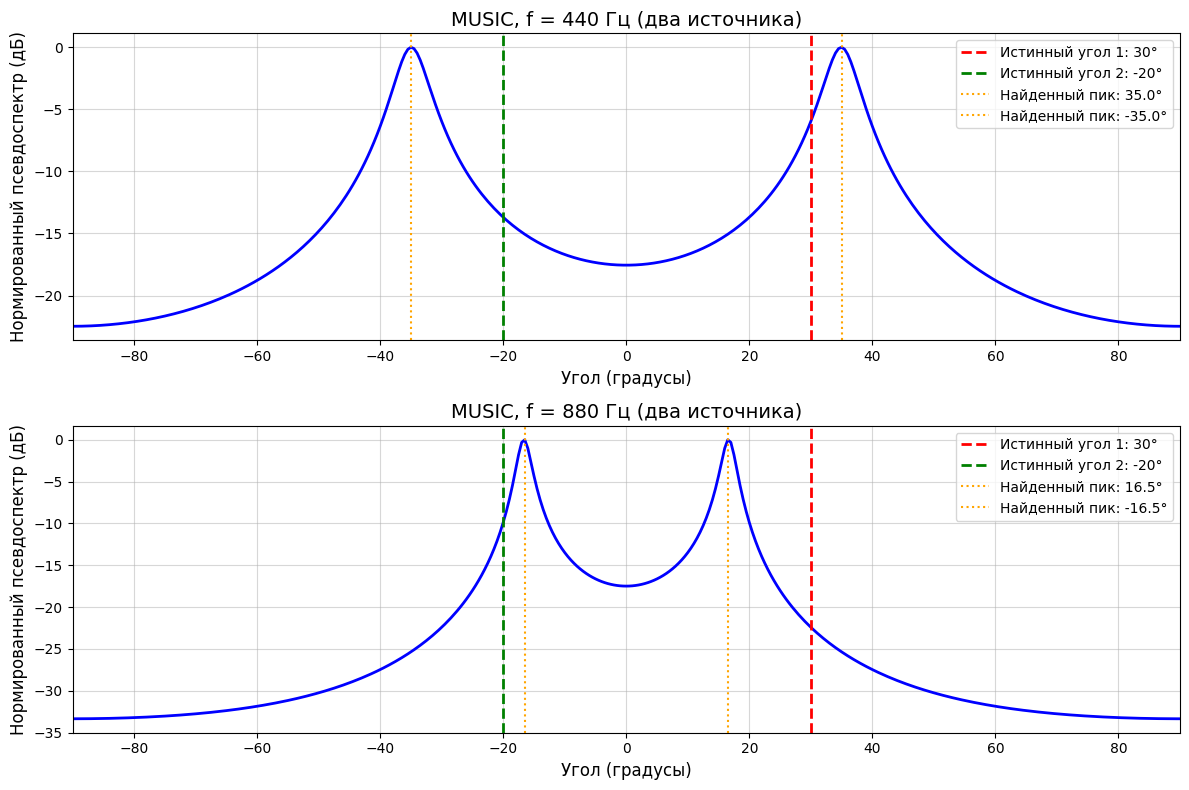

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

np.random.seed(42)

# 1. Генерация сигналов для нескольких источников

def generate_harmonic_signal(fs, T, f0, A=1.0):
    """Генерация гармонического сигнала"""
    t = np.arange(0, T, 1/fs)
    s = A * np.cos(2 * np.pi * f0 * t)
    return t, s

def generate_array_signals_multiple(signals, t, d, thetas, R=3.0, SNR_dB=30, c=340, fs=None):

    M = len(d)
    L = len(t)
    K = len(thetas)

    # расчет задержек для всех источников
    delays = []
    for theta in thetas:
        theta_rad = np.deg2rad(theta)
        tau = d * np.sin(theta_rad) / c
        delays.append(tau)

    # генерация сигналов
    attenuation = 1.0 / R
    X = np.zeros((M, L))

    for m in range(M):
        s_total = np.zeros(L)
        for k in range(K):
            delay_samples = np.round(delays[k][m] * fs).astype(int)
            s_delayed = np.zeros_like(signals[k])
            delay = delay_samples

            if delay >= 0:
                if delay > 0:
                    s_delayed[delay:] = signals[k][:-delay]
                else:
                    s_delayed[:] = signals[k][:]
            else:
                delay_abs = abs(delay)
                if delay_abs > 0:
                    s_delayed[:-delay_abs] = signals[k][delay_abs:]
                else:
                    s_delayed[:] = signals[k][:]

            s_total += attenuation * s_delayed

        signal_power = np.mean(s_total**2)
        if signal_power < 1e-12:
            signal_power = 1.0
        noise_power = signal_power / (10**(SNR_dB/10))
        noise = np.sqrt(noise_power) * np.random.randn(L)

        X[m, :] = s_total + noise

    return X, delays

# 2. MUSIC

def compute_covariance_matrix(X):
    """Вычисление выборочной ковариационной матрицы сигналов"""
    M = X.shape[0]
    L = X.shape[1]

    X_complex = np.zeros((M, L), dtype=complex)
    for m in range(M):
        X_fft = np.fft.fft(X[m, :])
        X_fft[L//2+1:] = 0
        X_complex[m, :] = np.fft.ifft(X_fft)

    R = np.zeros((M, M), dtype=complex)
    for n in range(L):
        x = X_complex[:, n]
        R += np.outer(x, np.conj(x))
    R /= L

    return R

def compute_steering_vector(d, theta, f0, c=340):
    """Вычисление вектора направлений"""
    theta_rad = np.deg2rad(theta)
    a = np.exp(-1j * 2 * np.pi * f0 * d * np.sin(theta_rad) / c)
    return a

def music_doa(X, d, theta_range, f0, c=340):
    """
    MUSIC: оценка углов прихода.

    Параметры:
        X : ndarray (M x L) — сигналы микрофонов
        d : ndarray (M) — координаты микрофонов
        theta_range : ndarray (N) — сетка углов (градусы)
        f0 : float — частота сигнала
        c : float — скорость звука

    Возвращает:
        spectrum : ndarray (N) — псевдоспектр
        eigvals : ndarray (M) — собственные значения
    """
    M = X.shape[0]
    L = X.shape[1]
    N_theta = len(theta_range)

    # демодуляция
    t = np.arange(L) / 48000
    ref = np.exp(-1j * 2 * np.pi * f0 * t)
    X_demod = np.zeros((M, L), dtype=complex)
    for m in range(M):
        X_demod[m, :] = X[m, :] * ref

    # ковариационная матрица
    R = np.zeros((M, M), dtype=complex)
    for n in range(L):
        x = X_demod[:, n]
        R += np.outer(x, np.conj(x))
    R /= L

    # регуляризация
    R += 1e-6 * np.trace(R) * np.eye(M)

    # собственные значения и векторы
    eigvals, eigvecs = np.linalg.eigh(R)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # шумовое подпространство
    K = 2
    U_n = eigvecs[:, K:]

    # псевдоспектр
    spectrum = np.zeros(N_theta)
    theta_rad = np.deg2rad(theta_range)

    for i, th in enumerate(theta_rad):
        a = np.exp(-1j * 2 * np.pi * f0 * d * np.sin(th) / c)
        denominator = np.linalg.norm(np.conj(a) @ U_n, ord=2) ** 2
        spectrum[i] = 1.0 / (denominator + 1e-12)

    return spectrum, eigvals

# 3. Поиск пиков

def find_peaks_spectrum(spectrum, theta_range, n_peaks=2, height_threshold=0.1):
    """
    Поиск n_peaks наибольших пиков в псевдоспектре.
    """
    peaks, properties = find_peaks(spectrum, height=height_threshold * np.max(spectrum))
    if len(peaks) == 0:
        return []
    heights = properties['peak_heights']
    sorted_idx = np.argsort(heights)[::-1]
    top_peaks = peaks[sorted_idx[:n_peaks]]
    return theta_range[top_peaks]

# 4. Демонстрация для 2-х источников

if __name__ == "__main__":

    print("MUSIC — ДВА ИСТОЧНИКА")

    # параметры
    fs = 48000
    T = 0.2
    M = 8
    delta_d = 0.05
    thetas_true = [30, -20]
    f0s = [440, 880]
    R = 3.0
    SNR_dB = 30
    c = 340

    print(f"\nПараметры:")
    print(f"  fs: {fs} Гц, T: {T} с")
    print(f"  Источник 1: {f0s[0]} Гц, θ = {thetas_true[0]}°")
    print(f"  Источник 2: {f0s[1]} Гц, θ = {thetas_true[1]}°")
    print(f"  Микрофонов: {M}, шаг: {delta_d*100:.0f} см")
    print(f"  SNR: {SNR_dB} дБ")

    d = (np.arange(M) - (M - 1) / 2) * delta_d
    print(f"\nКоординаты микрофонов: {d}")

    # генерация сигналов
    t, s1 = generate_harmonic_signal(fs, T, f0s[0])
    t, s2 = generate_harmonic_signal(fs, T, f0s[1])
    signals = [s1, s2]

    X, delays = generate_array_signals_multiple(signals, t, d, thetas_true, R, SNR_dB, fs=fs, c=c)

    print(f"\n1. Генерация сигналов...")
    print(f"   Размерность X: {X.shape}")
    print(f"   Теоретические задержки (крайние) для источника 1: {delays[0][-1] - delays[0][0]:.6f} с")
    print(f"   Теоретические задержки (крайние) для источника 2: {delays[1][-1] - delays[1][0]:.6f} с")

    # сканирование углов
    theta_range = np.linspace(-90, 90, 361)

    print("\n2. MUSIC оценка...")

    # MUSIC на частоте первого источника
    spectrum1, eigvals1 = music_doa(X, d, theta_range, f0s[0], c)
    peaks1 = find_peaks_spectrum(spectrum1, theta_range, n_peaks=2)

    # MUSIC на частоте второго источника
    spectrum2, eigvals2 = music_doa(X, d, theta_range, f0s[1], c)
    peaks2 = find_peaks_spectrum(spectrum2, theta_range, n_peaks=2)

    print("\n3. РЕЗУЛЬТАТЫ:")
    print(f"   Истинные углы: {thetas_true[0]}°, {thetas_true[1]}°")
    print(f"   MUSIC (f={f0s[0]} Гц): обнаружены углы {peaks1}")
    print(f"   MUSIC (f={f0s[1]} Гц): обнаружены углы {peaks2}")

    if len(peaks1) == 2:
        errors1 = np.min(np.abs(np.array(peaks1) - np.array(thetas_true)))
        print(f"   Ошибка для f={f0s[0]} Гц: {errors1:.2f}°")
    if len(peaks2) == 2:
        errors2 = np.min(np.abs(np.array(peaks2) - np.array(thetas_true)))
        print(f"   Ошибка для f={f0s[1]} Гц: {errors2:.2f}°")

    # визуализация
    print("\n4. Построение графиков...")

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # псевдоспектр на частоте f1
    axes[0].plot(theta_range, 10 * np.log10(spectrum1 / np.max(spectrum1) + 1e-12),
                 'b-', linewidth=2)
    axes[0].axvline(thetas_true[0], color='r', linestyle='--', linewidth=2,
                    label=f'Истинный угол 1: {thetas_true[0]}°')
    axes[0].axvline(thetas_true[1], color='g', linestyle='--', linewidth=2,
                    label=f'Истинный угол 2: {thetas_true[1]}°')
    for peak in peaks1:
        axes[0].axvline(peak, color='orange', linestyle=':', linewidth=1.5,
                        label=f'Найденный пик: {peak:.1f}°')

    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axes[0].legend(by_label.values(), by_label.keys(), fontsize=10)
    axes[0].set_xlabel('Угол (градусы)', fontsize=12)
    axes[0].set_ylabel('Нормированный псевдоспектр (дБ)', fontsize=12)
    axes[0].set_title(f'MUSIC, f = {f0s[0]} Гц (два источника)', fontsize=14)
    axes[0].grid(True, alpha=0.5)
    axes[0].set_xlim(-90, 90)

    # псевдоспектр на частоте f2
    axes[1].plot(theta_range, 10 * np.log10(spectrum2 / np.max(spectrum2) + 1e-12),
                 'b-', linewidth=2)
    axes[1].axvline(thetas_true[0], color='r', linestyle='--', linewidth=2,
                    label=f'Истинный угол 1: {thetas_true[0]}°')
    axes[1].axvline(thetas_true[1], color='g', linestyle='--', linewidth=2,
                    label=f'Истинный угол 2: {thetas_true[1]}°')
    for peak in peaks2:
        axes[1].axvline(peak, color='orange', linestyle=':', linewidth=1.5,
                        label=f'Найденный пик: {peak:.1f}°')
    handles, labels = axes[1].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axes[1].legend(by_label.values(), by_label.keys(), fontsize=10)
    axes[1].set_xlabel('Угол (градусы)', fontsize=12)
    axes[1].set_ylabel('Нормированный псевдоспектр (дБ)', fontsize=12)
    axes[1].set_title(f'MUSIC, f = {f0s[1]} Гц (два источника)', fontsize=14)
    axes[1].grid(True, alpha=0.5)
    axes[1].set_xlim(-90, 90)

    plt.tight_layout()
    plt.show()

Усовершенствованный MUSIC — два источника

Параметры:
  fs: 48000 Гц, T: 0.5 с
  Источник 1: 440 Гц, θ = 30°
  Источник 2: 880 Гц, θ = -20°
  Микрофонов: 8, шаг: 5 см
  SNR: 30 дБ

1. Генерация сигналов...
   Размерность X: (8, 24000)

2. Усовершенствованный MUSIC...

3. РЕЗУЛЬТАТЫ:
   Истинные углы: 30°, -20°
   Классический MUSIC: [ 29.5 -40.5]
   Усовершенствованный MUSIC: [ 29.5 -19.5]
   Ошибка классического MUSIC: 0.50°
   Ошибка усовершенствованного MUSIC: 0.50°


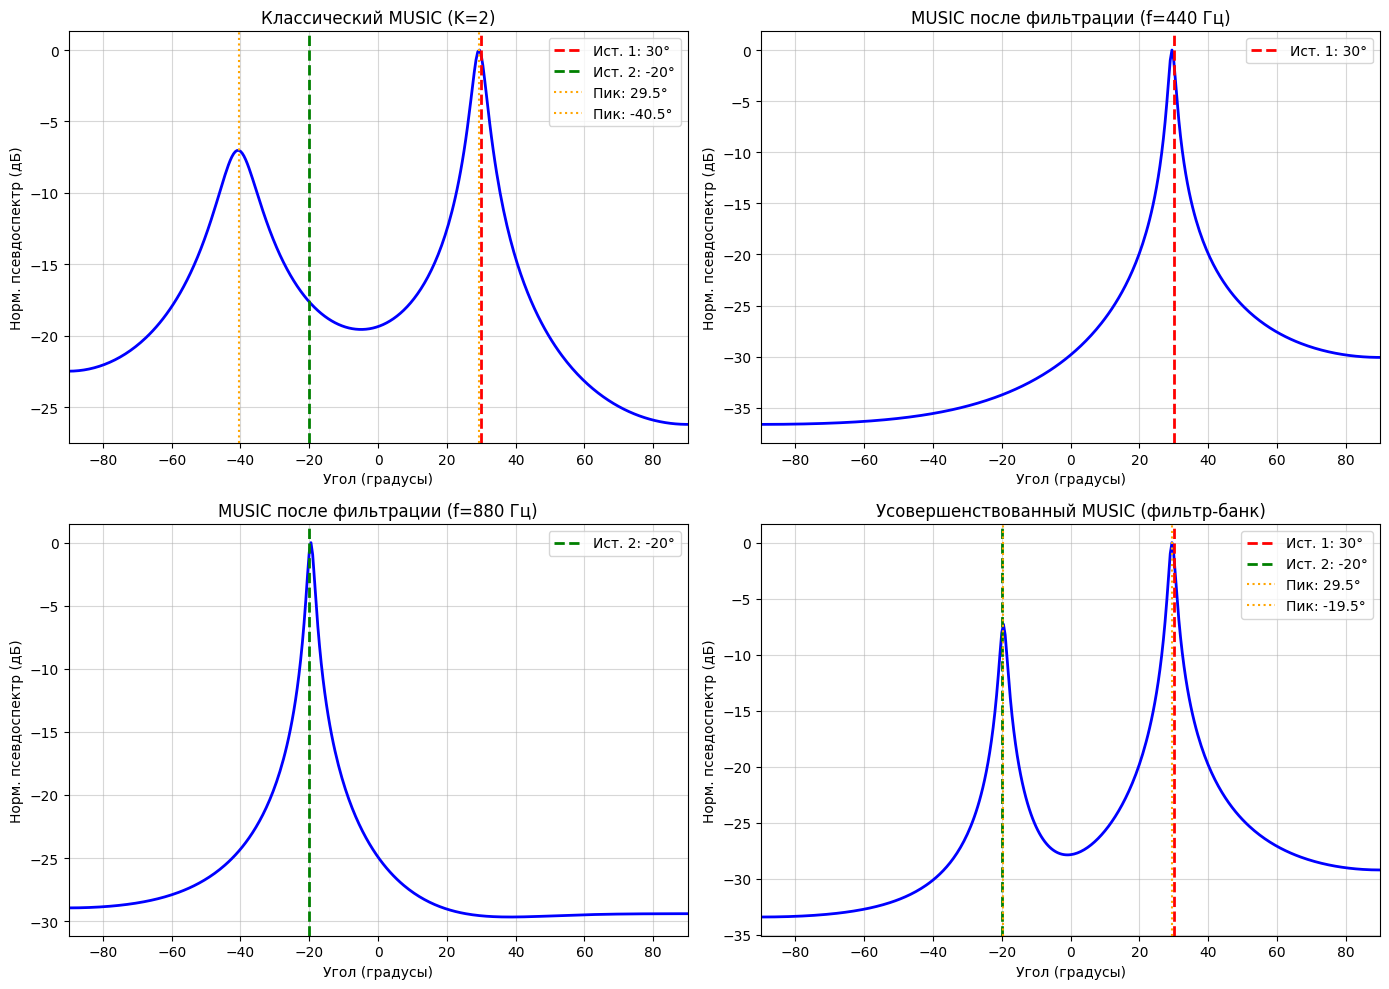

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.signal import find_peaks

np.random.seed(42)

# 1. Генерация сигналов

def generate_harmonic_signal(fs, T, f0, A=1.0):
    t = np.arange(0, T, 1/fs)
    s = A * np.cos(2 * np.pi * f0 * t)
    return t, s

def generate_array_signals(s1, s2, t, d, theta1, theta2, R=3.0, SNR_dB=30, c=340, fs=None):
    M = len(d)
    L = len(s1)

    theta1_rad = np.deg2rad(theta1)
    theta2_rad = np.deg2rad(theta2)

    tau1 = d * np.sin(theta1_rad) / c
    tau2 = d * np.sin(theta2_rad) / c

    tau1_samples = np.round(tau1 * fs).astype(int)
    tau2_samples = np.round(tau2 * fs).astype(int)

    attenuation = 1.0 / R
    X = np.zeros((M, L))

    for m in range(M):
        s1_delayed = np.zeros_like(s1)
        delay1 = tau1_samples[m]
        if delay1 >= 0:
            if delay1 > 0:
                s1_delayed[delay1:] = s1[:-delay1]
            else:
                s1_delayed[:] = s1[:]
        else:
            delay_abs = abs(delay1)
            if delay_abs > 0:
                s1_delayed[:-delay_abs] = s1[delay_abs:]
            else:
                s1_delayed[:] = s1[:]

        s2_delayed = np.zeros_like(s2)
        delay2 = tau2_samples[m]
        if delay2 >= 0:
            if delay2 > 0:
                s2_delayed[delay2:] = s2[:-delay2]
            else:
                s2_delayed[:] = s2[:]
        else:
            delay_abs = abs(delay2)
            if delay_abs > 0:
                s2_delayed[:-delay_abs] = s2[delay_abs:]
            else:
                s2_delayed[:] = s2[:]

        s_total = attenuation * (s1_delayed + s2_delayed)

        signal_power = np.mean(s_total**2)
        if signal_power < 1e-12:
            signal_power = 1.0
        noise_power = signal_power / (10**(SNR_dB/10))
        noise = np.sqrt(noise_power) * np.random.randn(L)

        X[m, :] = s_total + noise

    return X, tau1, tau2

# 2. Фильтрация

def bandpass_filter(X, f_low, f_high, fs, order=4):
    """Полосовая фильтрация сигнала"""
    nyquist = fs / 2
    b, a = butter(order, [f_low / nyquist, f_high / nyquist], btype='band')
    X_filtered = np.zeros_like(X)
    for m in range(X.shape[0]):
        X_filtered[m, :] = filtfilt(b, a, X[m, :])
    return X_filtered

# 3. MUSIC с регуляризацией

def compute_covariance_matrix(X):
    M = X.shape[0]
    L = X.shape[1]

    X_complex = np.zeros((M, L), dtype=complex)
    for m in range(M):
        X_fft = np.fft.fft(X[m, :])
        X_fft[L//2+1:] = 0
        X_complex[m, :] = np.fft.ifft(X_fft)

    R = np.zeros((M, M), dtype=complex)
    for n in range(L):
        x = X_complex[:, n]
        R += np.outer(x, np.conj(x))
    R /= L

    return R

def compute_steering_vector(d, theta, f0, c=340):
    theta_rad = np.deg2rad(theta)
    a = np.exp(-1j * 2 * np.pi * f0 * d * np.sin(theta_rad) / c)
    return a

def music_doa(X, d, theta_range, f0, c=340, K=1, reg=1e-3):
    """
    MUSIC с регуляризацией.
    """
    M = X.shape[0]
    L = X.shape[1]
    N_theta = len(theta_range)

    # демодуляция
    t = np.arange(L) / 48000
    ref = np.exp(-1j * 2 * np.pi * f0 * t)
    X_demod = np.zeros((M, L), dtype=complex)
    for m in range(M):
        X_demod[m, :] = X[m, :] * ref

    # ковариационная матрица
    R = compute_covariance_matrix(X_demod)
    R += reg * np.trace(R) * np.eye(M)

    # собственные значения и векторы
    try:
        eigvals, eigvecs = np.linalg.eigh(R)
    except np.linalg.LinAlgError:
        eigvals, eigvecs = np.linalg.eig(R)
        eigvals = np.real(eigvals)

    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # шумовое подпространство
    U_n = eigvecs[:, K:]

    # псевдоспектр
    spectrum = np.zeros(N_theta)
    for i, theta in enumerate(theta_range):
        a = compute_steering_vector(d, theta, f0, c)
        denominator = np.linalg.norm(np.conj(a) @ U_n, ord=2) ** 2
        spectrum[i] = 1.0 / (denominator + 1e-12)

    return spectrum, eigvals

# 4. Усовершенствованный MUSIC

def music_new(X, d, theta_range, f1, f2, c=340, fs=48000):
    """
    Усовершенствованный MUSIC для двух источников.
    """
    # фильтрация
    X_filtered_1 = bandpass_filter(X, f1-30, f1+30, fs, order=4)
    X_filtered_2 = bandpass_filter(X, f2-30, f2+30, fs, order=4)

    # MUSIC для каждого источника (K=1)
    spectrum_1, _ = music_doa(X_filtered_1, d, theta_range, f1, c, K=1, reg=1e-3)
    spectrum_2, _ = music_doa(X_filtered_2, d, theta_range, f2, c, K=1, reg=1e-3)

    # объединение спектров
    spectrum_combined = spectrum_1 + spectrum_2
    spectrum_combined = spectrum_combined / np.max(spectrum_combined)

    return spectrum_combined, spectrum_1, spectrum_2

# 5. Поиск пиков

def find_peaks_spectrum(spectrum, theta_range, n_peaks=2, height_threshold=0.05):
    peaks, properties = find_peaks(spectrum, height=height_threshold * np.max(spectrum))
    if len(peaks) == 0:
        return []
    heights = properties['peak_heights']
    sorted_idx = np.argsort(heights)[::-1]
    top_peaks = peaks[sorted_idx[:n_peaks]]
    return theta_range[top_peaks]

# 6. Демонстрация

if __name__ == "__main__":

    print("Усовершенствованный MUSIC — два источника")

    # параметры
    fs = 48000
    T = 0.5
    M = 8
    delta_d = 0.05
    theta1_true = 30
    theta2_true = -20
    f1 = 440
    f2 = 880
    R = 3.0
    SNR_dB = 30
    c = 340

    print(f"\nПараметры:")
    print(f"  fs: {fs} Гц, T: {T} с")
    print(f"  Источник 1: {f1} Гц, θ = {theta1_true}°")
    print(f"  Источник 2: {f2} Гц, θ = {theta2_true}°")
    print(f"  Микрофонов: {M}, шаг: {delta_d*100:.0f} см")
    print(f"  SNR: {SNR_dB} дБ")

    d = (np.arange(M) - (M - 1) / 2) * delta_d

    # генерация сигналов
    t, s1 = generate_harmonic_signal(fs, T, f1)
    t, s2 = generate_harmonic_signal(fs, T, f2)
    X, tau1, tau2 = generate_array_signals(s1, s2, t, d, theta1_true, theta2_true, R, SNR_dB, fs=fs, c=c)

    print(f"\n1. Генерация сигналов...")
    print(f"   Размерность X: {X.shape}")

    # сканирование углов
    theta_range = np.linspace(-90, 90, 361)

    print("\n2. Усовершенствованный MUSIC...")

    # классический MUSIC (без фильтрации)
    spectrum_classic, _ = music_doa(X, d, theta_range, f1, c, K=2, reg=1e-3)
    peaks_classic = find_peaks_spectrum(spectrum_classic, theta_range, n_peaks=2)

    # усовершенствованный MUSIC
    spectrum_enhanced, spectrum_1, spectrum_2 = music_new(X, d, theta_range, f1, f2, c, fs)
    peaks_enhanced = find_peaks_spectrum(spectrum_enhanced, theta_range, n_peaks=2)

    print("\n3. РЕЗУЛЬТАТЫ:")
    print(f"   Истинные углы: {theta1_true}°, {theta2_true}°")
    print(f"   Классический MUSIC: {peaks_classic}")
    print(f"   Усовершенствованный MUSIC: {peaks_enhanced}")

    if len(peaks_classic) == 2:
        error_classic = np.min(np.abs(np.array(peaks_classic) - np.array([theta1_true, theta2_true])))
        print(f"   Ошибка классического MUSIC: {error_classic:.2f}°")

    if len(peaks_enhanced) == 2:
        error_enhanced = np.min(np.abs(np.array(peaks_enhanced) - np.array([theta1_true, theta2_true])))
        print(f"   Ошибка усовершенствованного MUSIC: {error_enhanced:.2f}°")

    # визуализация
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # классический MUSIC
    axes[0, 0].plot(theta_range, 10 * np.log10(spectrum_classic / np.max(spectrum_classic) + 1e-12), 'b-', linewidth=2)
    axes[0, 0].axvline(theta1_true, color='r', linestyle='--', linewidth=2, label=f'Ист. 1: {theta1_true}°')
    axes[0, 0].axvline(theta2_true, color='g', linestyle='--', linewidth=2, label=f'Ист. 2: {theta2_true}°')
    for peak in peaks_classic:
        axes[0, 0].axvline(peak, color='orange', linestyle=':', linewidth=1.5, label=f'Пик: {peak:.1f}°')
    axes[0, 0].set_xlabel('Угол (градусы)')
    axes[0, 0].set_ylabel('Норм. псевдоспектр (дБ)')
    axes[0, 0].set_title('Классический MUSIC (K=2)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.5)
    axes[0, 0].set_xlim(-90, 90)

    # источник 1 (после фильтрации)
    axes[0, 1].plot(theta_range, 10 * np.log10(spectrum_1 / np.max(spectrum_1) + 1e-12), 'b-', linewidth=2)
    axes[0, 1].axvline(theta1_true, color='r', linestyle='--', linewidth=2, label=f'Ист. 1: {theta1_true}°')
    axes[0, 1].set_xlabel('Угол (градусы)')
    axes[0, 1].set_ylabel('Норм. псевдоспектр (дБ)')
    axes[0, 1].set_title(f'MUSIC после фильтрации (f={f1} Гц)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.5)
    axes[0, 1].set_xlim(-90, 90)

    # источник 2 (после фильтрации)
    axes[1, 0].plot(theta_range, 10 * np.log10(spectrum_2 / np.max(spectrum_2) + 1e-12), 'b-', linewidth=2)
    axes[1, 0].axvline(theta2_true, color='g', linestyle='--', linewidth=2, label=f'Ист. 2: {theta2_true}°')
    axes[1, 0].set_xlabel('Угол (градусы)')
    axes[1, 0].set_ylabel('Норм. псевдоспектр (дБ)')
    axes[1, 0].set_title(f'MUSIC после фильтрации (f={f2} Гц)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.5)
    axes[1, 0].set_xlim(-90, 90)

    # усовершенствованный MUSIC
    axes[1, 1].plot(theta_range, 10 * np.log10(spectrum_enhanced / np.max(spectrum_enhanced) + 1e-12), 'b-', linewidth=2)
    axes[1, 1].axvline(theta1_true, color='r', linestyle='--', linewidth=2, label=f'Ист. 1: {theta1_true}°')
    axes[1, 1].axvline(theta2_true, color='g', linestyle='--', linewidth=2, label=f'Ист. 2: {theta2_true}°')
    for peak in peaks_enhanced:
        axes[1, 1].axvline(peak, color='orange', linestyle=':', linewidth=1.5, label=f'Пик: {peak:.1f}°')
    axes[1, 1].set_xlabel('Угол (градусы)')
    axes[1, 1].set_ylabel('Норм. псевдоспектр (дБ)')
    axes[1, 1].set_title('Усовершенствованный MUSIC (фильтр-банк)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.5)
    axes[1, 1].set_xlim(-90, 90)

    plt.tight_layout()
    plt.show()

Последовательная локализация трех источников

Параметры:
  fs: 48000 Гц, T: 0.5 с
  Источник 1: 440 Гц, θ = 40°
  Источник 2: 660 Гц, θ = 0°
  Источник 3: 880 Гц, θ = -40°
  Микрофонов: 12, шаг: 5 см
  SNR: 30 дБ

Координаты микрофонов: [-0.275 -0.225 -0.175 -0.125 -0.075 -0.025  0.025  0.075  0.125  0.175
  0.225  0.275]

1. Генерация сигналов...
   Размерность X: (12, 24000)

2. Последовательная локализация...
  Шаг 1 (f=440 Гц): найден угол 40.0°
  Шаг 2 (f=660 Гц): найден угол -9.0°
  Шаг 3 (f=880 Гц): найден угол -39.0°


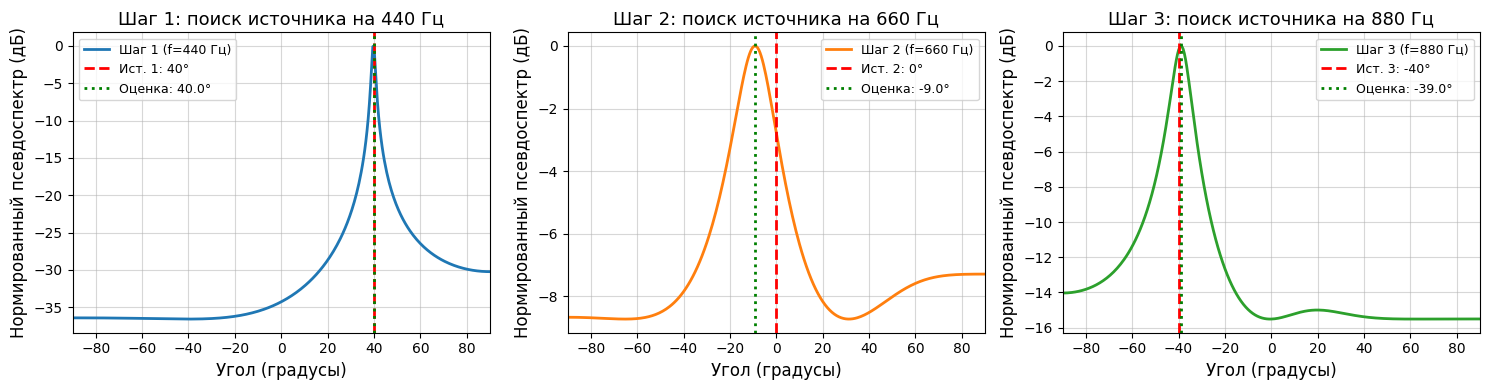


3. РЕЗУЛЬТАТЫ:
   Истинные углы: [40, 0, -40]
   Оцененные углы: [np.float64(40.0), np.float64(-9.0), np.float64(-39.0)]
   Источник 1: ошибка 0.00°
   Источник 2: ошибка 9.00°
   Источник 3: ошибка 1.00°
   Средняя ошибка: 3.33°


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.signal import find_peaks

np.random.seed(42)

# 1. Генерация сигналов

def generate_harmonic_signal(fs, T, f0, A=1.0):
    t = np.arange(0, T, 1/fs)
    s = A * np.cos(2 * np.pi * f0 * t)
    return t, s

def generate_array_signals_multiple(signals, t, d, thetas, f0s, R=3.0, SNR_dB=30, c=340, fs=None):
    M = len(d)
    L = len(t)
    K = len(thetas)

    delays = []
    for theta in thetas:
        theta_rad = np.deg2rad(theta)
        tau = d * np.sin(theta_rad) / c
        delays.append(tau)

    attenuation = 1.0 / R
    X = np.zeros((M, L))

    for m in range(M):
        s_total = np.zeros(L)
        for k in range(K):
            delay_samples = np.round(delays[k][m] * fs).astype(int)
            s_delayed = np.zeros_like(signals[k])
            delay = delay_samples

            if delay >= 0:
                if delay > 0:
                    s_delayed[delay:] = signals[k][:-delay]
                else:
                    s_delayed[:] = signals[k][:]
            else:
                delay_abs = abs(delay)
                if delay_abs > 0:
                    s_delayed[:-delay_abs] = signals[k][delay_abs:]
                else:
                    s_delayed[:] = signals[k][:]

            s_total += attenuation * s_delayed

        signal_power = np.mean(s_total**2)
        if signal_power < 1e-12:
            signal_power = 1.0
        noise_power = signal_power / (10**(SNR_dB/10))
        noise = np.sqrt(noise_power) * np.random.randn(L)

        X[m, :] = s_total + noise

    return X, delays

# 2. Фильтрация и MUSIC

def bandpass_filter(X, f_low, f_high, fs, order=4):
    nyquist = fs / 2
    b, a = butter(order, [f_low / nyquist, f_high / nyquist], btype='band')
    X_filtered = np.zeros_like(X)
    for m in range(X.shape[0]):
        X_filtered[m, :] = filtfilt(b, a, X[m, :])
    return X_filtered

def compute_covariance_matrix(X):
    M = X.shape[0]
    L = X.shape[1]

    X_complex = np.zeros((M, L), dtype=complex)
    for m in range(M):
        X_fft = np.fft.fft(X[m, :])
        X_fft[L//2+1:] = 0
        X_complex[m, :] = np.fft.ifft(X_fft)

    R = np.zeros((M, M), dtype=complex)
    for n in range(L):
        x = X_complex[:, n]
        R += np.outer(x, np.conj(x))
    R /= L

    return R

def compute_steering_vector(d, theta, f0, c=340):
    theta_rad = np.deg2rad(theta)
    a = np.exp(-1j * 2 * np.pi * f0 * d * np.sin(theta_rad) / c)
    return a

def music_doa(X, d, theta_range, f0, c=340, K=1, reg=1e-3):
    M = X.shape[0]
    L = X.shape[1]
    N_theta = len(theta_range)

    t = np.arange(L) / 48000
    ref = np.exp(-1j * 2 * np.pi * f0 * t)
    X_demod = np.zeros((M, L), dtype=complex)
    for m in range(M):
        X_demod[m, :] = X[m, :] * ref

    R = compute_covariance_matrix(X_demod)
    R += reg * np.trace(R) * np.eye(M)

    try:
        eigvals, eigvecs = np.linalg.eigh(R)
    except np.linalg.LinAlgError:
        eigvals, eigvecs = np.linalg.eig(R)
        eigvals = np.real(eigvals)

    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    U_n = eigvecs[:, K:]

    spectrum = np.zeros(N_theta)
    for i, theta in enumerate(theta_range):
        a = compute_steering_vector(d, theta, f0, c)
        denominator = np.linalg.norm(np.conj(a) @ U_n, ord=2) ** 2
        spectrum[i] = 1.0 / (denominator + 1e-12)

    return spectrum, eigvals

def find_peaks_spectrum(spectrum, theta_range, n_peaks=1, height_threshold=0.05):
    peaks, properties = find_peaks(spectrum, height=height_threshold * np.max(spectrum))
    if len(peaks) == 0:
        return []
    heights = properties['peak_heights']
    sorted_idx = np.argsort(heights)[::-1]
    top_peaks = peaks[sorted_idx[:n_peaks]]
    return theta_range[top_peaks]

# 3. Последовательная локализация

def sequential_music_with_plots(X, d, theta_range, f0s, thetas_true, c=340, fs=48000):
    M = X.shape[0]
    L = X.shape[1]

    estimated_thetas = []
    spectra_history = []
    X_residual = X.copy().astype(np.complex128)

    for step, f0 in enumerate(f0s):
        X_filtered_real = bandpass_filter(np.real(X_residual), f0-30, f0+30, fs, order=4)
        spectrum, _ = music_doa(X_filtered_real, d, theta_range, f0, c, K=1, reg=1e-3)
        spectra_history.append(spectrum.copy())

        peaks = find_peaks_spectrum(spectrum, theta_range, n_peaks=1)
        if len(peaks) == 0:
            print(f"  Источник на частоте {f0} Гц не найден")
            continue

        theta_est = peaks[0]
        estimated_thetas.append(theta_est)
        print(f"  Шаг {step+1} (f={f0} Гц): найден угол {theta_est:.1f}°")

        theta_rad = np.deg2rad(theta_est)
        tau = d * np.sin(theta_rad) / c
        tau_samples = np.round(tau * fs).astype(int)

        s_est = np.zeros(L, dtype=np.complex128)
        for m in range(M):
            s_est += X_residual[m, :] * np.exp(1j * 2 * np.pi * f0 * tau_samples[m] / fs)
        s_est = s_est / M
        s_est_real = np.real(s_est)

        for m in range(M):
            delay = tau_samples[m]
            s_delayed = np.zeros_like(s_est_real)
            if delay >= 0:
                if delay > 0:
                    s_delayed[delay:] = s_est_real[:-delay]
                else:
                    s_delayed[:] = s_est_real[:]
            else:
                delay_abs = abs(delay)
                if delay_abs > 0:
                    s_delayed[:-delay_abs] = s_est_real[delay_abs:]
                else:
                    s_delayed[:] = s_est_real[:]
            X_residual[m, :] -= 0.8 * s_delayed

        X_residual[np.abs(X_residual) < 1e-6] = 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    labels = [f'Шаг 1 (f={f0s[0]} Гц)', f'Шаг 2 (f={f0s[1]} Гц)', f'Шаг 3 (f={f0s[2]} Гц)']

    for i, (spectrum, f0) in enumerate(zip(spectra_history, f0s)):
        axes[i].plot(theta_range, 10 * np.log10(spectrum / np.max(spectrum) + 1e-12),
                     color=colors[i], linewidth=2, label=labels[i])
        axes[i].axvline(thetas_true[i], color='r', linestyle='--', linewidth=2,
                        label=f'Ист. {i+1}: {thetas_true[i]}°')
        if len(estimated_thetas) > i:
            axes[i].axvline(estimated_thetas[i], color='g', linestyle=':', linewidth=2,
                            label=f'Оценка: {estimated_thetas[i]:.1f}°')
        axes[i].set_xlabel('Угол (градусы)', fontsize=12)
        axes[i].set_ylabel('Нормированный псевдоспектр (дБ)', fontsize=12)
        axes[i].set_title(f'Шаг {i+1}: поиск источника на {f0} Гц', fontsize=13)
        axes[i].legend(fontsize=9)
        axes[i].grid(True, alpha=0.5)
        axes[i].set_xlim(-90, 90)

    plt.tight_layout()
    plt.savefig('sequential_music_three_sources.png', dpi=300, bbox_inches='tight')
    plt.show()

    return estimated_thetas

# 4. Демонстрация

if __name__ == "__main__":

    print("Последовательная локализация трех источников")

    fs = 48000
    T = 0.5
    M = 12
    delta_d = 0.05
    thetas_true = [40, 0, -40]
    f0s = [440, 660, 880]
    R = 3.0
    SNR_dB = 30
    c = 340

    print(f"\nПараметры:")
    print(f"  fs: {fs} Гц, T: {T} с")
    for i, (f0, theta) in enumerate(zip(f0s, thetas_true)):
        print(f"  Источник {i+1}: {f0} Гц, θ = {theta}°")
    print(f"  Микрофонов: {M}, шаг: {delta_d*100:.0f} см")
    print(f"  SNR: {SNR_dB} дБ")

    d = (np.arange(M) - (M - 1) / 2) * delta_d
    print(f"\nКоординаты микрофонов: {d}")

    t, signals = [], []
    for f0 in f0s:
        t_i, s_i = generate_harmonic_signal(fs, T, f0)
        t = t_i
        signals.append(s_i)

    X, delays = generate_array_signals_multiple(signals, t, d, thetas_true, f0s, R, SNR_dB, fs=fs, c=c)

    print(f"\n1. Генерация сигналов...")
    print(f"   Размерность X: {X.shape}")

    theta_range = np.linspace(-90, 90, 361)

    print("\n2. Последовательная локализация...")
    estimated_thetas = sequential_music_with_plots(X, d, theta_range, f0s, thetas_true, c, fs)

    print("\n3. РЕЗУЛЬТАТЫ:")
    print(f"   Истинные углы: {thetas_true}")
    print(f"   Оцененные углы: {estimated_thetas}")

    if len(estimated_thetas) == len(thetas_true):
        errors = []
        for i, (true, est) in enumerate(zip(thetas_true, estimated_thetas)):
            error = abs(true - est)
            errors.append(error)
            print(f"   Источник {i+1}: ошибка {error:.2f}°")
        print(f"   Средняя ошибка: {np.mean(errors):.2f}°")